# Summary of training results

In this notebook we provide an overview of the training results.

In [1]:
import glob
import json
import re
from collections import defaultdict
import matplotlib.pyplot as plt

from utils.metadata import total_runtime

In [ ]:
graph_types = [
    ("erdos_renyi", "Erdos Renyi", r"ER\d*"), 
    ("heavy_hex", "Heavy hexagonal lattice", "HH??"), 
    ("random_regular", "Random $k$-regular", "R?R"),
    ("line_to_full", "Swap layer based", "L2S?"),
]

all_counts = dict()
methods = set()
all_train_durations = 0

for folder, pretty_name, pattern in graph_types:
    all_counts[pretty_name] = defaultdict(int)
    for file_name in glob.glob(f"../data/training/{folder}/*"):
        name = file_name.replace(f"../data/training/{folder}", "")
        sub_names = name.split("_")
        graph_idx = sub_names[2][0:3]
        match = re.match(r"^N\d{1,3}", sub_names[2][3:]).span()
        idx1, idx2 = match[0]+4, match[1]+3
        node_number = int(sub_names[2][idx1:idx2])
        all_counts[pretty_name][node_number] += 1
        #print(match, name, graph_idx, node_number)

        with open(file_name, "r") as fin:
            data = json.load(fin)

        methods.add(data["args"]["config"])

        all_train_durations += total_runtime(data)

In [3]:
all_data_count = 0
for _, val in all_counts.items():
    all_data_count += sum(val.values())

all_data_count

1065

In [4]:
all_train_durations / 60 / 60

136.55493168009653

Text(0, 0.5, 'Number of solution files')

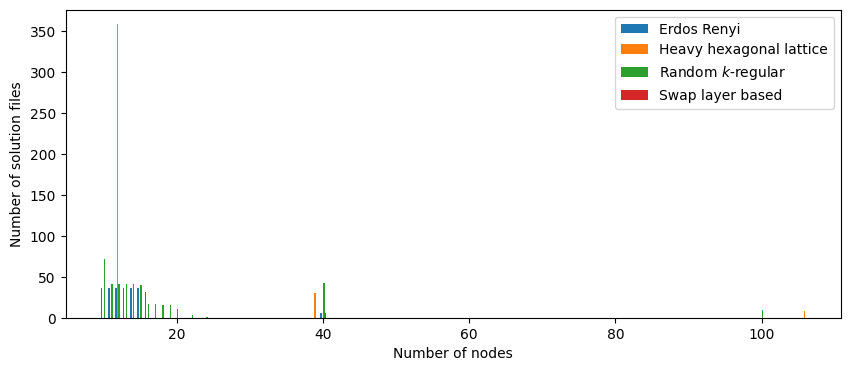

In [5]:
fig, axs = plt.subplots(1, 1, figsize=(10, 4))

offset = -0.3
for folder, pretty_name, pattern in graph_types:
    axs.bar([val + offset for val in all_counts[pretty_name].keys()], all_counts[pretty_name].values(), label=pretty_name, width=0.2)
    offset += 0.2

axs.legend()
axs.set_xlabel("Number of nodes")
axs.set_ylabel("Number of solution files")